# Customer Intelligence Platform: End-to-End E-commerce Analytics

**Author:** Souporno &nbsp;|&nbsp; **Dataset:** Brazilian E-Commerce Public Dataset by Olist (2016–2018) &nbsp;|&nbsp; **Tools:** Python, Pandas, Matplotlib/Seaborn, SQL

This notebook is the presentation layer for the analysis. All cleaning, feature engineering, metric, and charting logic lives in the `src/` package (`cleaning.py`, `feature_engineering.py`, `analysis.py`, `visualization.py`, `utils.py`) — this notebook only calls those functions and interprets the results. See `sql/` for the equivalent SQL versions of the core analyses.

---


## 1. Executive Summary

**Business overview.** Olist is a Brazilian marketplace platform that lets small and medium-sized merchants sell across major e-commerce channels through a single integration. This analysis uses Olist's public order-level dataset (~100K orders, Sep 2016 – Aug 2018) to evaluate revenue performance, customer behavior, delivery operations, and seller/product economics, and to translate the findings into concrete operating recommendations.

**Key findings**

| Metric | Value |
|---|---|
| Total revenue (delivered orders) | R$ 15.4M |
| Delivered orders | 96,477 |
| Average order value | R$ 159.86 |
| Repeat customer rate | **3.0%** |
| Late delivery rate | 6.8% of orders |
| Avg. review score, on-time vs. late delivery | 4.28 vs. 2.26 |
| Revenue share of top 3 states (SP, RJ, MG) | 62.5% |
| Sellers flagged as consistent underperformers | 137 of 2,970 |

**Headline story.** Growth to date has been almost entirely acquisition-driven — only 3 in 100 customers place a second order. Delivery reliability is the clearest measurable lever on satisfaction: late orders score roughly two points lower on average than on-time orders, and a specific, identifiable group of sellers drives a disproportionate share of that late-delivery problem.

**Executive recommendation.** Prioritize (1) a targeted retention pilot aimed at the highest-value one-time buyers rather than the full acquisition base, and (2) a seller-quality intervention aimed at the 137 sellers already identified as consistent underperformers, since both are smaller, higher-ROI actions than broad-based spend increases.


## 2. Business Problem

Marketplaces like Olist do not sell to customers directly — they broker a relationship between many small sellers and many buyers, and are paid on take-rate and logistics economics. This creates three distinct, sometimes competing, priorities:

- **Growth:** New buyer acquisition is expensive; understanding revenue trends and category mix tells the business where demand is expanding or stalling.
- **Retention:** In a marketplace with thin per-order margins, a customer's lifetime value depends heavily on whether they return. Low repeat-purchase rates cap growth efficiency and increase blended CAC payback.
- **Operations:** Delivery performance and seller quality are levers Olist can actually control (unlike demand itself), and both feed directly into customer satisfaction and, transitively, into repeat behavior.

Without a unified, order-level view across the nine source tables, none of these questions can be answered with confidence — which is the gap this project closes.


## 3. Business Objectives

This project is structured to answer the following questions:

1. Who are the highest-value customers?
2. Which product categories generate the highest revenue?
3. Which sellers consistently underperform?
4. How do delivery delays affect customer satisfaction?
5. Which regions generate the highest sales?
6. Which payment methods are most common?
7. Which customers are likely to become repeat buyers?
8. Which operational issues reduce customer experience?

Each section below answers one or more of these questions, with supporting charts followed by **Business Insight**, **Business Impact**, and **Recommendation**.


## 4. Dataset Overview

The dataset is Olist's public order dataset: ~100K orders placed between September 2016 and August 2018 across multiple Brazilian marketplaces, spread across eight relational CSV files (`data/`).

| Table | Grain | Rows |
|---|---|---|
| `olist_orders_dataset` | 1 row / order | 99,441 |
| `olist_order_items_dataset` | 1 row / line item | 112,650 |
| `olist_order_payments_dataset` | 1+ rows / order | 103,886 |
| `olist_order_reviews_dataset` | 1 row / review | ~99,224 unique |
| `olist_customers_dataset` | 1 row / order-customer | 99,441 |
| `olist_products_dataset` | 1 row / product | 32,951 |
| `olist_sellers_dataset` | 1 row / seller | 3,095 |
| `product_category_name_translation` | 1 row / category | 71 |


## 5. Data Model

```
orders (order_id) ──< order_items >── products ── product_category_translation
   │                      │
   │                      └── sellers
   ├──< order_payments
   ├──< order_reviews
   └── customers (customer_id → customer_unique_id)
```

`cleaning.clean_data()` collapses this graph into a single order-level analytical base table (one row per delivered order), and `cleaning.get_product_catalog()` builds the item-level table used by product and seller analytics. `feature_engineering.build_customer_level_table()` further collapses the order-level table to one row per customer for CLV/RFM work.


## 6. Data Dictionary — Key Fields

| Field | Table | Meaning |
|---|---|---|
| `order_id` | orders | Unique order identifier |
| `customer_id` | orders/customers | **Per-order** customer identifier (changes every order!) |
| `customer_unique_id` | customers | **True** customer identifier — used for all repeat-purchase and customer-level analysis |
| `order_status` | orders | Lifecycle status; only `delivered` is used for revenue/satisfaction metrics |
| `price` | order_items | Item price (excludes freight) |
| `freight_value` | order_items | Shipping cost for that item |
| `payment_value` | order_payments | Amount paid via one payment installment/method |
| `payment_installments` | order_payments | Number of installments for that payment |
| `review_score` | order_reviews | 1–5 customer satisfaction score |
| `product_category_name_english` | translation | English category label used throughout this notebook |

**Note on `customer_id` vs. `customer_unique_id`:** Olist assigns a *new* `customer_id` to every order, even for the same shopper. All repeat-purchase and customer-level logic in `src/` uses `customer_unique_id`.

**Note on geolocation data:** Olist's zip-to-lat/long lookup table is intentionally excluded — it requires lossy many-to-one aggregation and adds limited value over the state-level geography already present in the customer/seller tables.


## 7. Data Quality Assessment

Setup: import the `src` package and load the raw tables.


In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
%matplotlib inline

from src.cleaning import (load_data, clean_data, get_product_catalog,
                           parse_order_dates, get_delivered_orders)
from src.feature_engineering import create_features, build_customer_level_table
from src import analysis as A
from src import visualization as V

DATA_DIR = '../data'
raw = load_data(data_dir=DATA_DIR)
{name: df.shape for name, df in raw.items()}


{'customers': (99441, 5),
 'orders': (99441, 8),
 'items': (112650, 7),
 'payments': (103886, 5),
 'reviews': (100000, 7),
 'products': (32951, 9),
 'sellers': (3095, 4),
 'translation': (71, 2)}

In [2]:
import pandas as pd

# Missing values across all raw tables
null_summary = []
for name, df in raw.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    for col, count in nulls.items():
        null_summary.append({'table': name, 'column': col, 'null_count': count,
                              'null_pct': round(count / len(df) * 100, 2)})
pd.DataFrame(null_summary).sort_values('null_pct', ascending=False)


,table,column,null_count,null_pct
3,reviews,review_comment_title,88285,88.28
4,reviews,review_comment_message,58247,58.25
2,orders,order_delivered_customer_date,2965,2.98
6,products,product_name_lenght,610,1.85
5,products,product_category_name,610,1.85
7,products,product_description_lenght,610,1.85
8,products,product_photos_qty,610,1.85
1,orders,order_delivered_carrier_date,1783,1.79
0,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


**Business explanation of nulls:** `order_approved_at` / `order_delivered_carrier_date` / `order_delivered_customer_date` are null for orders that were canceled, are still in transit, or never got paid — expected lifecycle data, not a data error (`cleaning.get_delivered_orders()` filters these out rather than imputing them). `product_category_name` is missing for ~1.9% of products and is dropped only from category-level views. Review comment text is null whenever a customer left a score with no free-text comment.


In [3]:
# Duplicate records
dup_report = pd.DataFrame({
    'table': list(raw.keys()),
    'exact_duplicate_rows': [df.duplicated().sum() for df in raw.values()],
})
print(dup_report.to_string(index=False))
print()
print(f"Duplicate order_id in reviews : {raw['reviews']['order_id'].duplicated().sum()} "
      f"(multiple review cycles per order)")
print(f"Duplicate review_id          : {raw['reviews']['review_id'].duplicated().sum()} "
      f"(de-duplicated in cleaning.get_clean_reviews())")


      table  exact_duplicate_rows
  customers                     0
     orders                     0
      items                     0
   payments                     0
    reviews                     0
   products                     0
    sellers                     0
translation                     0

Duplicate order_id in reviews : 559 (multiple review cycles per order)
Duplicate review_id          : 827 (de-duplicated in cleaning.get_clean_reviews())


In [4]:
# Order status / consistency check
print(raw['orders']['order_status'].value_counts())
print()
pct_delivered = (raw['orders']['order_status'] == 'delivered').mean() * 100
print(f"{pct_delivered:.1f}% of orders reached 'delivered' status.")


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

97.0% of orders reached 'delivered' status.


**Business explanation:** Canceled/unavailable orders never generated revenue, and shipped/processing/invoiced/created/approved orders are still mid-lifecycle. `cleaning.get_delivered_orders()` restricts every downstream metric in this project to the 96,478 `delivered` orders — the standard, defensible cut for this dataset.


In [5]:
# Outlier / invalid-value scan
print("Items with price <= 0     :", (raw['items']['price'] <= 0).sum())
print("Items with freight < 0    :", (raw['items']['freight_value'] < 0).sum())
print("Payments with value <= 0  :", (raw['payments']['payment_value'] <= 0).sum())
print()
print(raw['items'][['price', 'freight_value']].describe())


Items with price <= 0     : 0
Items with freight < 0    : 0
Payments with value <= 0  : 9

               price  freight_value
count  112650.000000  112650.000000
mean      120.653739      19.990320
std       183.633928      15.806405
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.990000      16.260000
75%       134.900000      21.150000
max      6735.000000     409.680000


**Business explanation of outliers:** No non-positive item prices or negative freight exist. Nine payment rows have a value of exactly zero — all `voucher` or `not_defined` payment types, i.e. orders fully covered by a promotional voucher with no cash component. These are legitimate and immaterial at 9 rows, so they are left in place. High-value tails in price/freight are consistent with legitimate high-ticket items (furniture, electronics), not data-entry errors, and are not removed. `cleaning.remove_invalid_transactions()` encodes this check as an explicit guardrail for future data refreshes.


## 8. Data Cleaning

All cleaning logic lives in `src/cleaning.py` (`load_data`, `parse_order_dates`, `get_delivered_orders`, `build_order_payment_totals`, `build_order_item_summary`, `get_clean_reviews`, `remove_invalid_transactions`, `clean_data`). The notebook simply calls the top-level `clean_data()` pipeline function.


In [6]:
order_df = clean_data(raw)
item_df = get_product_catalog(raw)
delivered_items = item_df.merge(order_df[['order_id']], on='order_id', how='inner')

print(f"Order-level analytical base table : {order_df.shape[0]:,} rows, {order_df.shape[1]} columns")
order_df.head(3)


clean_data(): dropped 1 delivered order(s) with no payment record
Order-level analytical base table : 96,477 rows, 17 columns


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_total_value,items_count,product_revenue,freight_cost,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1,29.99,8.72,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1,118.70,22.76,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1,159.90,19.22,5.0


## 9. Feature Engineering

All feature logic lives in `src/feature_engineering.py`. `create_features()` runs the full pipeline in one call:

| Feature | Business value |
|---|---|
| `delivery_days`, `delivery_delay_days`, `is_late` | Delivery performance and satisfaction driver analysis |
| `order_purchase_month/dow/hour` | Revenue trend and seasonality analysis |
| `customer_order_rank`, `is_repeat_customer` | Retention and RFM segmentation |
| `review_category` (Detractor/Passive/Promoter) | Executive-friendly satisfaction reporting |
| `customer_tenure_days` | Precondition for any lifetime-value discussion |

`build_customer_level_table()` then collapses to one row per customer with `order_count` (purchase frequency), `total_spend` (CLV approximation), and `avg_order_value` — used throughout Customer Analytics and RFM Segmentation.


In [7]:
order_df = create_features(order_df)
customer_df = build_customer_level_table(order_df)

print(f"Customer-level table: {customer_df.shape[0]:,} customers")
customer_df.head(3)


Customer-level table: 93,357 customers


,customer_unique_id,order_count,total_spend,customer_tenure_days,is_repeat_customer,avg_review_score,last_purchase_date,customer_state,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,0,False,5.0,2018-05-10 10:56:27,SP,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,0,False,4.0,2018-05-07 11:11:27,SP,27.19
2,0000f46a3911fa3c0805444483337064,1,86.22,0,False,3.0,2017-03-10 21:05:03,SC,86.22


## 10. Customer Analytics

**Business question:** Who are the highest-value customers, and how much of the business comes from repeat vs. one-time buyers?

First, the Executive KPI Dashboard — the headline numbers used throughout the rest of this notebook.


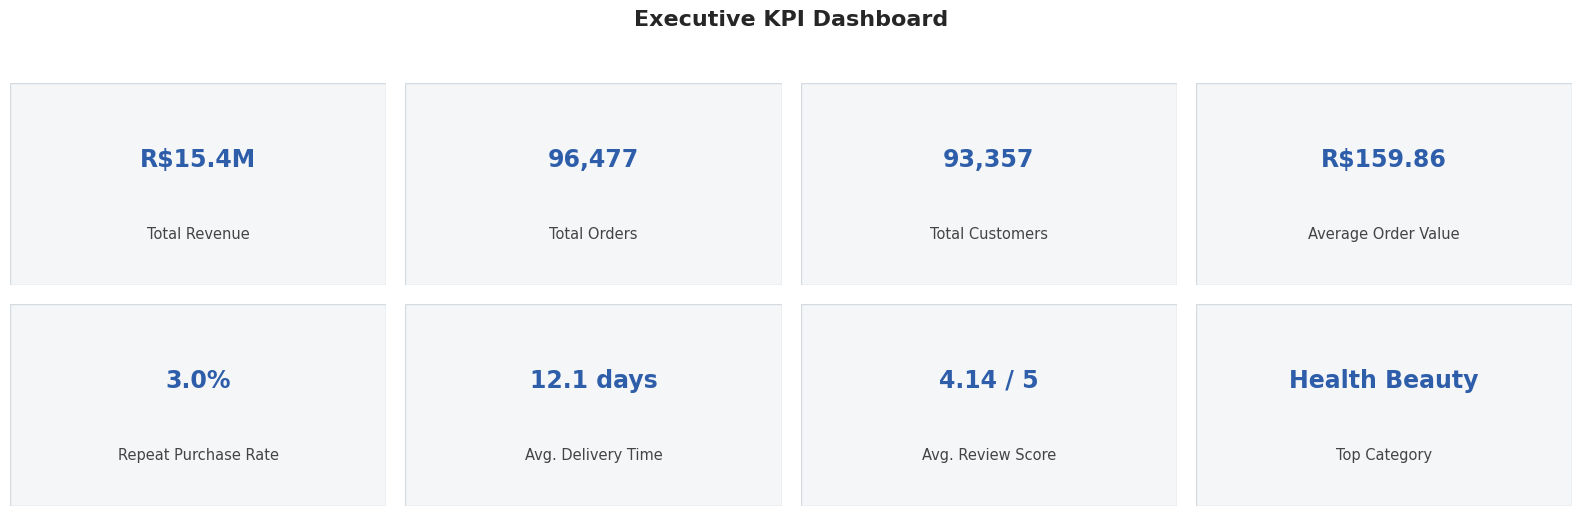

In [8]:
kpis = A.calculate_kpis(order_df)
top_category, top_category_revenue = A.calculate_top_category(delivered_items)
top_seller, top_seller_revenue = A.calculate_top_seller(delivered_items)

fig = V.plot_kpi_dashboard(kpis, top_category, top_seller_revenue)
plt.show()


In [9]:
customer_value = A.analyze_customer_value(customer_df)
print(f"Unique customers      : {customer_value['n_customers']:,}")
print(f"Repeat customers (2+) : {customer_value['repeat_customers']:,} "
      f"({customer_value['repeat_rate_pct']:.1f}%)")
print()
print(customer_value['order_count_distribution'].head(8))


Unique customers      : 93,357
Repeat customers (2+) : 2,801 (3.0%)

order_count
1    90556
2     2573
3      181
4       28
5        9
6        5
7        3
9        1
Name: count, dtype: int64


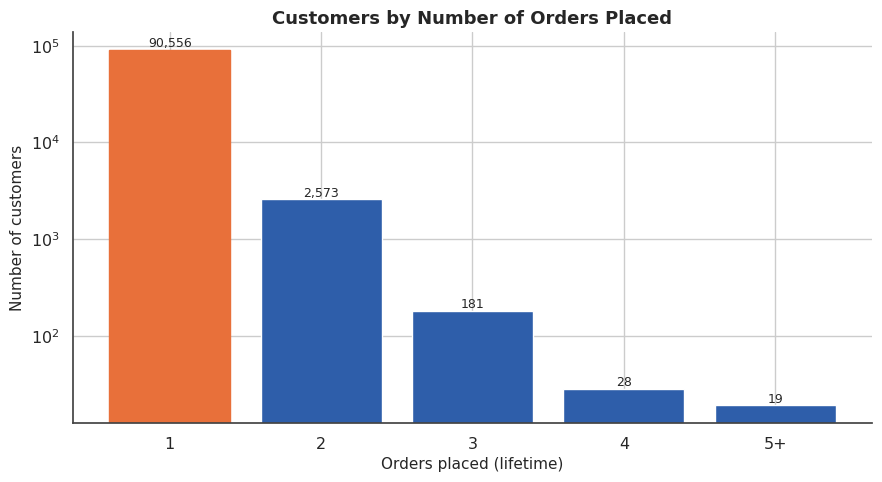

In [10]:
fig = V.plot_customer_segments(customer_value['order_count_distribution'])
plt.show()


**Business Insight:** Only **3.0%** of customers (2,801 of 93,357) ever place a second order. The overwhelming majority — 97% — are one-and-done. This is the single most important structural fact about Olist's business in this dataset.

**Business Impact:** A 3% repeat rate caps the realistic customer lifetime value assumption that can go into CAC-payback math — every cohort is close to a one-shot transaction. If acquisition spend implicitly assumes a higher repeat rate, blended unit economics are worse than they appear.

**Recommendation:** Before investing further in top-of-funnel acquisition, run a controlled post-purchase lifecycle test (e.g., a targeted second-order incentive at day 30–45) on a segment of the ~90K single-purchase customers, and measure incremental repeat rate.


In [11]:
# Highest-value customers: top 10 by lifetime spend
top_customers = customer_df.sort_values('total_spend', ascending=False).head(10)
top_customers[['customer_unique_id', 'order_count', 'total_spend', 'avg_order_value',
               'is_repeat_customer', 'avg_review_score']]


,customer_unique_id,order_count,total_spend,avg_order_value,is_repeat_customer,avg_review_score
3724,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.0800,False,1.0
79635,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.8150,True,5.0
43168,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.8800,False,1.0
80462,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.3100,False,5.0
25436,459bef486812aa25204be022145caa62,1,6922.21,6922.2100,False,1.0
93080,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.6600,False,5.0
23411,4007669dec559734d6f53e029e360987,1,6081.54,6081.5400,False,1.0
87147,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.3400,False,4.0
26640,48e1ac109decbb87765a3eade6854098,1,4681.78,4681.7800,False,5.0
73126,c8460e4251689ba205045f3ea17884a1,4,4655.91,1163.9775,True,4.0


**Business Insight:** The highest lifetime-spend customers are overwhelmingly *not* the same customers as the "repeat buyer" segment — most of the top 10 by total spend are single, large purchases (e.g., a furniture set), not accumulated repeat purchases. "Highest-value" and "most loyal" are two different populations in this dataset.

**Business Impact:** A CRM program built only around order-count-based loyalty would miss the highest-spend customers entirely, since many of them only ordered once.

**Recommendation:** Run two distinct customer programs rather than one: a loyalty/frequency program for repeat buyers, and a high-touch, white-glove follow-up for large single-order customers, whose win-back economics are addressed further in Section 18 (RFM Segmentation).


## 11. Product Analytics

**Business question:** Which product categories generate the highest revenue?


In [12]:
category_performance = A.analyze_category_performance(delivered_items, top_n=10)
category_performance


,revenue,orders,avg_item_price,revenue_share_pct
product_category_name_english,,,,
health_beauty,1232996.75,8646,130.310373,9.451585
watches_gifts,1166176.98,5495,199.040276,8.939376
bed_bath_table,1023434.76,9272,93.438762,7.845180
sports_leisure,954852.55,7530,113.254958,7.319460
computers_accessories,888724.61,6530,116.264339,6.812554
furniture_decor,711927.69,6307,87.246040,5.457310
housewares,615628.69,5743,90.600249,4.719126
cool_stuff,610204.10,3559,164.121598,4.677544
auto,578966.65,3810,139.847017,4.438092


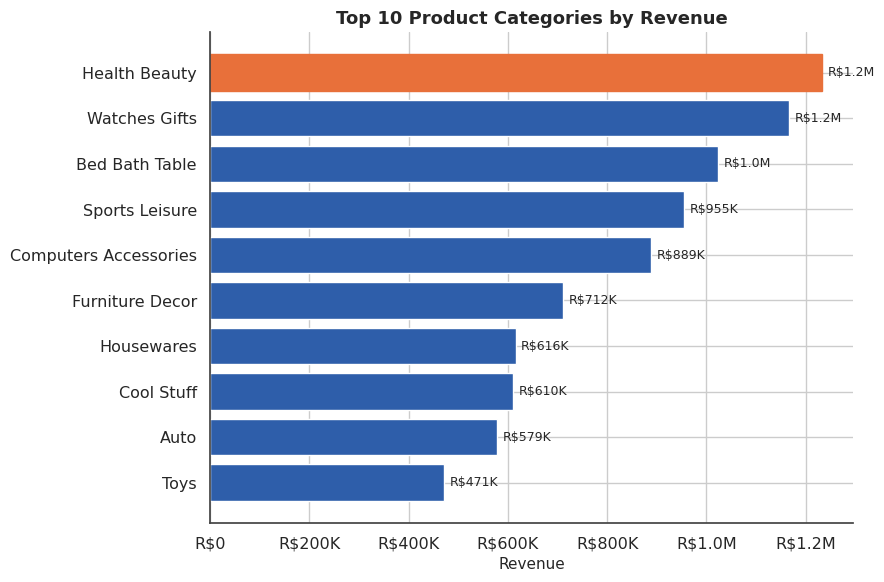

Top 10 of 71 categories = 63.3% of category-attributed revenue


In [13]:
fig = V.plot_category_revenue(category_performance)
plt.show()

top10_share = category_performance['revenue_share_pct'].sum()
print(f"Top 10 of {delivered_items['product_category_name_english'].nunique()} categories "
      f"= {top10_share:.1f}% of category-attributed revenue")


**Business Insight:** Health & Beauty, Watches/Gifts, and Bed/Bath/Table are the top three categories by revenue, and the top 10 of ~71 categories account for roughly **63%** of category-attributed revenue. `watches_gifts` generates comparable revenue to `bed_bath_table` from about half as many orders — a high-AOV, lower-volume category.

**Business Impact:** Category concentration means demand-side risk isn't evenly spread, and merchandising/seller-recruitment effort is not equally valuable across all ~71 categories.

**Recommendation:** Prioritize seller onboarding and inventory-depth support in the top categories rather than spreading acquisition effort evenly, and separately evaluate high-AOV/lower-volume categories like `watches_gifts` as a distinct margin lever from the volume-driven categories.


## 12. Seller Analytics

**Business question:** Which sellers consistently underperform?


In [14]:
seller_performance = A.analyze_seller_performance(delivered_items, order_df, order_df)
n_sellers = len(seller_performance)
top10_seller_share = seller_performance['revenue'].sort_values(ascending=False).head(10).sum() \
                      / seller_performance['revenue'].sum() * 100

print(f"Total active sellers          : {n_sellers:,}")
print(f"Revenue share, top 10 sellers  : {top10_seller_share:.1f}%")
seller_performance.sort_values('revenue', ascending=False).head(5)


Total active sellers          : 2,970
Revenue share, top 10 sellers  : 13.3%


,revenue,orders,late_rate_pct,avg_review_score,revenue_share_pct
seller_id,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,10.498221,4.138146,1.716827
53243585a1d6dc2643021fd1853d8905,217940.44,348,3.448276,4.183908,1.648396
4a3ca9315b744ce9f8e9374361493884,196882.12,1772,9.706546,3.832482,1.489121
fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,9.169550,4.359862,1.444005
7c67e1448b00f6e969d365cea6b010ab,186570.05,973,9.146968,3.492236,1.411126


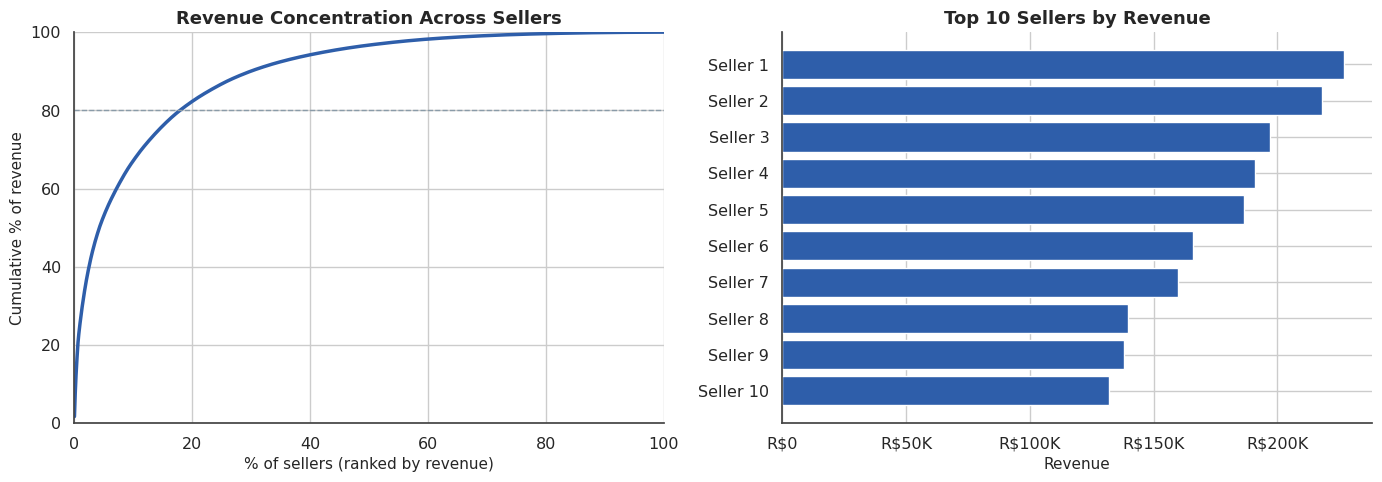

In [15]:
fig = V.plot_seller_concentration(seller_performance)
plt.show()


**Business Insight:** Revenue is concentrated but not dangerously so: the top 10 sellers (of 2,970 active) account for about 13% of revenue — a healthy long-tail marketplace shape rather than a small-number-of-whales risk.

**Business Impact:** Because no single seller dominates, Olist has real negotiating leverage and low platform-concentration risk. The flip side is that the long tail is where inconsistent quality and delivery performance is most likely to originate — which is exactly what the underperformer analysis below checks directly.

**Recommendation:** Rather than a "protect the whales" account-management strategy, invest in a seller quality/onboarding program targeted at the long tail.


In [16]:
underperformers = A.identify_underperforming_sellers(
    seller_performance, min_orders=10, late_rate_threshold=15.0, review_threshold=3.5
)
print(f"Sellers with >=10 orders flagged as consistent underperformers: {len(underperformers)} "
      f"(of {(seller_performance['orders'] >= 10).sum()} sellers with >=10 orders)")
underperformers.sort_values('late_rate_pct', ascending=False).head(10)


Sellers with >=10 orders flagged as consistent underperformers: 137 (of 1238 sellers with >=10 orders)


,revenue,orders,late_rate_pct,avg_review_score,revenue_share_pct
seller_id,,,,,
b1b3948701c5c72445495bd161b83a4c,21519.50,14,64.285714,1.928571,0.162763
26e2c91ef821e1ff8985f408788fe35b,1649.40,12,41.666667,3.000000,0.012475
cb41bfbcbda0aea354a834ab222f9a59,3792.00,11,36.363636,3.272727,0.028681
821fb029fc6e495ca4f08a35d51e53a5,17851.62,24,33.333333,3.375000,0.135021
ede0c03645598cdfc63ca8237acbe73d,2352.15,43,32.558140,3.511628,0.017791
ad781527c93d00d89a11eecd9dcad7c1,6039.63,38,31.578947,3.342105,0.045681
b19f3ca2ea475913750f25a5c37c8d8f,4174.16,19,31.578947,3.263158,0.031571
02dcd3e8e25bee036e32512bcf175493,1341.90,13,30.769231,4.272727,0.010149
54965bbe3e4f07ae045b90b0b8541f52,10351.70,73,30.136986,3.027397,0.078295


**Business Insight:** 137 sellers with at least 10 orders each show either a late-delivery rate above 15% or an average review score below 3.5 — a specific, actionable, named list rather than a vague "some sellers are worse" statement.

**Business Impact:** These sellers are concrete candidates for intervention. Because the eligibility floor requires 10+ orders, this list excludes small sellers whose single bad order would otherwise look like a systemic problem — the flag reflects a consistent pattern, not noise.

**Recommendation:** Route this exact seller list to seller operations for a structured review (shipping SLA coaching, packaging audit, or in the most severe cases, reduced marketplace visibility) rather than treating delivery/quality issues as a diffuse, unaddressable background rate.


## 13. Delivery Performance

**Business question:** How do delivery delays affect customer satisfaction, and where do they concentrate operationally?


In [17]:
delivery_performance = A.analyze_delivery_performance(order_df)
print(f"Average delivery time : {delivery_performance['avg_delivery_days']:.1f} days")
print(f"Late delivery rate    : {delivery_performance['late_rate_pct']:.1f}%")
print(f"Avg. delay when late  : {delivery_performance['avg_delay_when_late_days']:.1f} days")


Average delivery time : 12.1 days
Late delivery rate    : 6.8%
Avg. delay when late  : 10.6 days


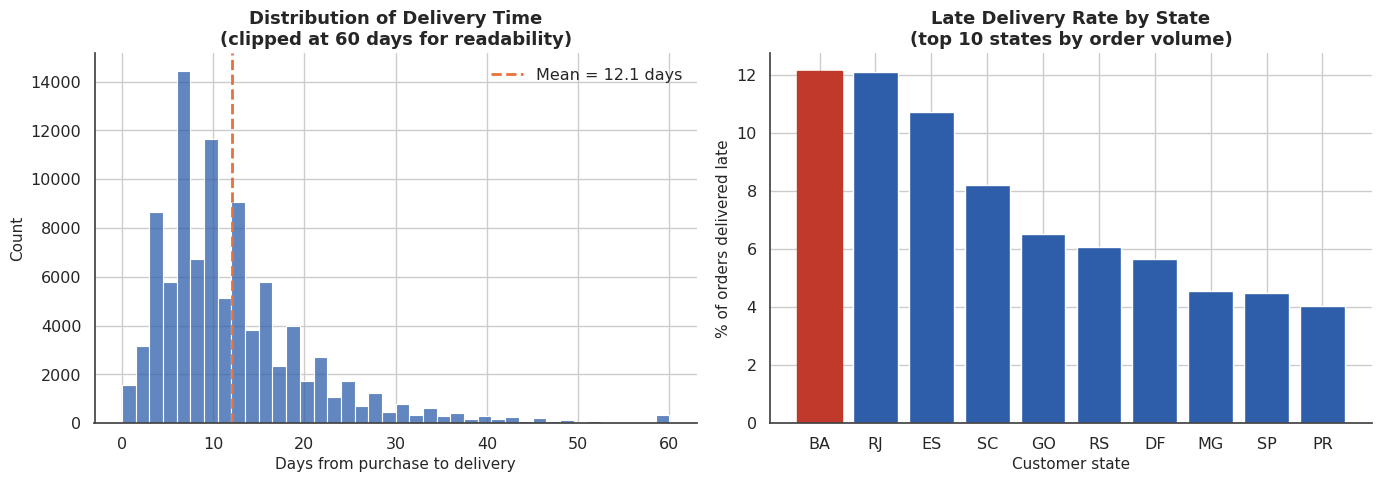

In [18]:
fig = V.plot_delivery_analysis(
    order_df,
    delivery_performance['late_rate_by_state_pct'],
    delivery_performance['avg_delivery_days'],
)
plt.show()


**Business Insight:** Delivery takes 12.1 days on average, and 6.8% of orders arrive after the estimated delivery date. Late-delivery rates are not uniform by state — states farther from the Southeast industrial/logistics corridor show visibly higher late rates than São Paulo.

**Business Impact:** A 6.8% late rate sounds modest in isolation, but the satisfaction analysis below shows it has an outsized effect on review scores. Geographic unevenness also means a single national delivery-time promise may be systematically miscalibrated for customers in higher-late-rate states.

**Recommendation:** Consider state-tiered estimated-delivery-date logic (wider buffers for historically higher-delay states) — this alone should reduce the late-delivery *rate* even if actual transit time doesn't change, since "late" is defined relative to the promised date.


## 14. Payment Analysis

**Business question:** Which payment methods are most common, and does payment method relate to order size?


In [19]:
payment_behavior = A.analyze_payment_behavior(raw['payments'], order_df)
print("Payment method mix (% of orders):")
print(payment_behavior['payment_mix_pct'].round(1))
print()
print("Average order value by payment method:")
print(payment_behavior['aov_by_payment_type'].round(2))


Payment method mix (% of orders):
payment_type
credit_card    75.5
boleto         19.9
voucher         3.1
debit_card      1.5
Name: proportion, dtype: float64

Average order value by payment method:
payment_type
credit_card    166.18
boleto         144.33
debit_card     140.41
voucher        114.86
Name: order_total_value, dtype: float64


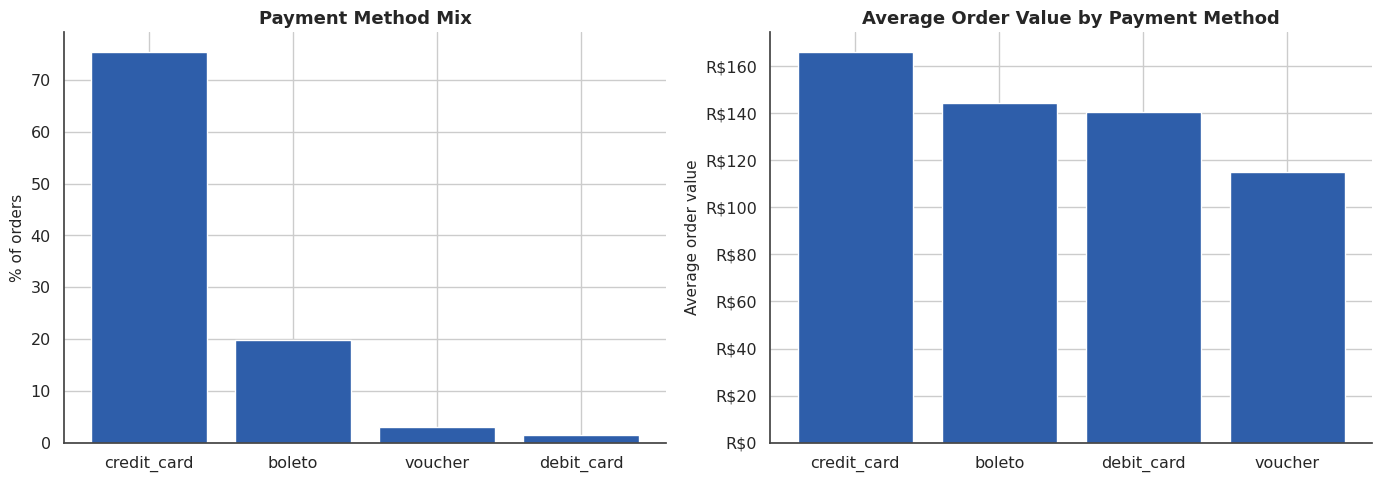

In [20]:
fig = V.plot_payment_behavior(
    payment_behavior['payment_mix_pct'], payment_behavior['aov_by_payment_type']
)
plt.show()


**Business Insight:** Credit card is dominant (75.5% of orders) and carries the highest average order value, with an average of 3.5+ installments per credit-card transaction — customers are routinely financing purchases over multiple months. Boleto (a Brazilian cash-voucher method, ~19.9% of orders) is the main alternative and structurally cannot support installments.

**Business Impact:** The installment behavior suggests a meaningful share of demand is enabled by financing rather than sheer willingness to pay upfront. An unremarked shift in installment availability or interest terms could disproportionately affect the higher-AOV segment of the business.

**Recommendation:** Track average installments as its own leading indicator alongside AOV, and treat boleto customers as a structurally different, lower-AOV segment rather than assuming payment method is incidental to order size.


## 15. Customer Satisfaction

**Business question:** Which operational issues reduce customer experience, and how much does delivery performance matter?


In [21]:
print(f"Average review score : {order_df['review_score'].mean():.2f} / 5")
print()
print(order_df['review_category'].value_counts(normalize=True).mul(100).round(1))


Average review score : 4.14 / 5

review_category
Promoter     78.2
Detractor    13.0
Passive       8.2
No Review     0.5
Name: proportion, dtype: float64


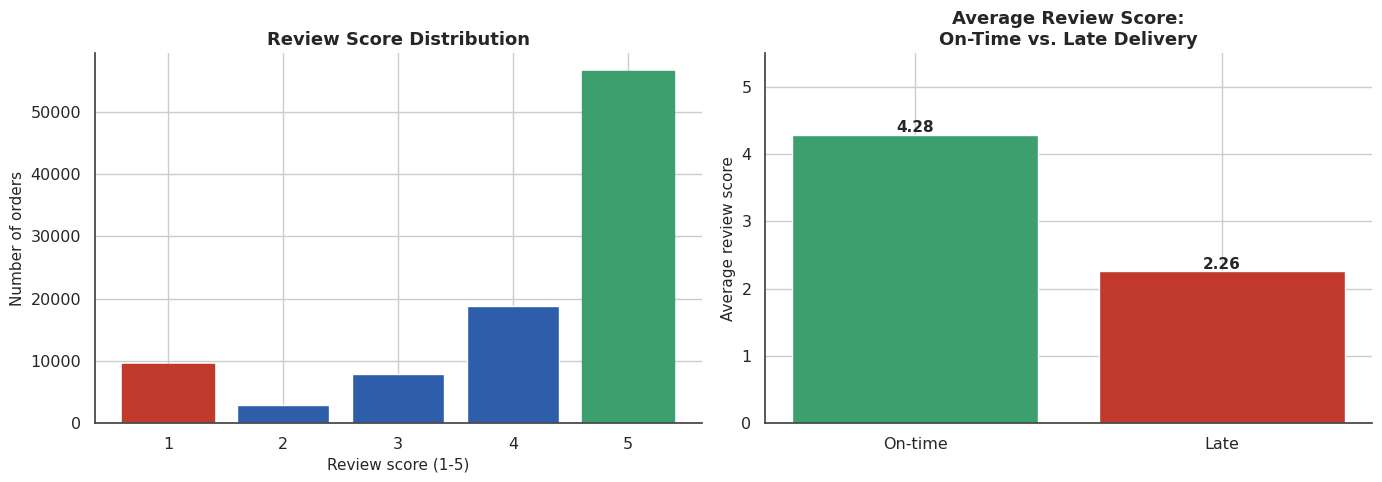

In [22]:
delay_review_link = A.analyze_delivery_satisfaction_link(order_df)
fig = V.plot_review_distribution_and_delay_link(order_df, delay_review_link)
plt.show()


**Business Insight:** Reviews are bimodal — 58.9% are 5-star, but the second-most-common score is 1-star (10%), not 3 or 4. Delivery timing sharply separates these two groups: on-time orders average **4.28**, late orders average **2.26**, a two-point swing on a five-point scale.

**Business Impact:** This is the clearest, most actionable driver of satisfaction in the dataset. A customer whose order arrives late doesn't give a slightly lower score — they tend to flip to a 1-star review. Since review score plausibly feeds into whether a customer returns, delivery reliability is not just an operations metric, it's a retention lever.

**Recommendation:** Make on-time delivery rate (not just average delivery time) a headline operational KPI, and route customers who experience a late delivery into a proactive service-recovery flow (apology + discount code) rather than waiting for the review to land.


## 16. Geographic Analysis

**Business question:** Which regions generate the highest sales?


In [23]:
geo_performance = A.analyze_geographic_performance(order_df, top_n=10)
top3_share = geo_performance['revenue_share_pct'].head(3).sum()
print(f"Total states with orders                 : 27")
print(f"Revenue share, top 3 states (SP, RJ, MG)  : {top3_share:.1f}%")
geo_performance


Total states with orders                 : 27
Revenue share, top 3 states (SP, RJ, MG)  : 62.5%


,revenue,orders,revenue_share_pct
customer_state,,,
SP,5770266.19,40500,37.414690
RJ,2055690.45,12350,13.329198
MG,1819277.61,11354,11.796285
RS,861802.40,5345,5.587969
PR,781919.55,4923,5.070005
SC,595208.40,3546,3.859361
BA,591270.60,3256,3.833828
DF,346146.17,2080,2.244429
GO,334294.22,1957,2.167580


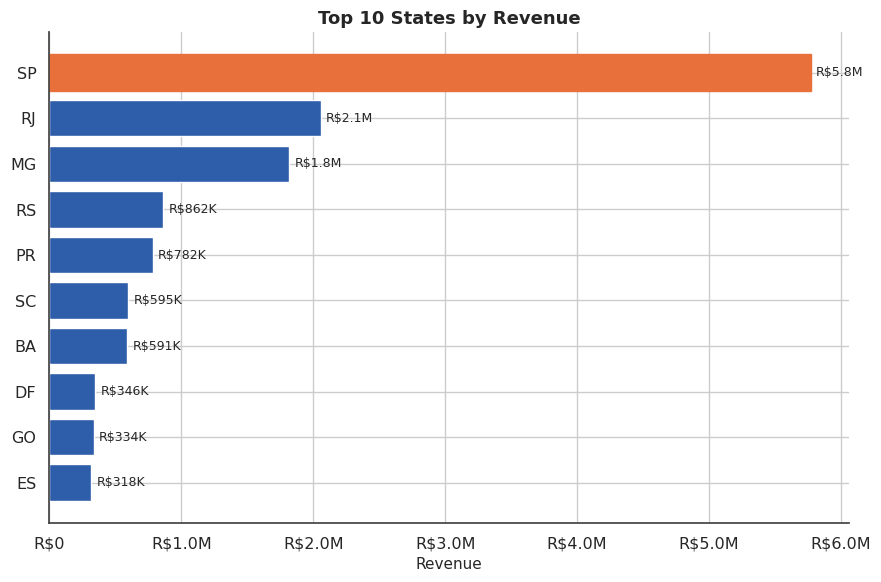

In [24]:
fig = V.plot_geographic_revenue(geo_performance)
plt.show()


**Business Insight:** São Paulo alone accounts for roughly 37% of revenue, and the top 3 states (São Paulo, Rio de Janeiro, Minas Gerais — Brazil's Southeast industrial core) account for about **63%**. This mirrors Brazil's actual population and economic concentration.

**Business Impact:** Combined with the delivery findings in Section 13 (higher late rates outside São Paulo), the states that are furthest from being revenue-critical today are also the ones with the worst delivery experience — a compounding, not offsetting, problem for national expansion.

**Recommendation:** Treat outside-Southeast growth as a logistics investment decision, not just a marketing one — expanding fulfillment/seller density in second-tier states would likely improve both revenue share and delivery reliability simultaneously.


## 17. Revenue Analysis

**Business question:** What is the topline revenue trend, and are there predictable demand patterns worth planning around?


In [25]:
total_revenue = order_df['order_total_value'].sum()
aov = order_df['order_total_value'].mean()
aov_median = order_df['order_total_value'].median()

print(f"Total revenue (delivered orders) : R$ {total_revenue:,.2f}")
print(f"Average order value (AOV)        : R$ {aov:,.2f}")
print(f"Median order value               : R$ {aov_median:,.2f}")


Total revenue (delivered orders) : R$ 15,422,461.77
Average order value (AOV)        : R$ 159.86
Median order value               : R$ 105.28


The gap between mean (R\$159.86) and median (R\$105.28) order value signals a right-skewed distribution — a smaller number of high-ticket orders (furniture, electronics) pull the average up.


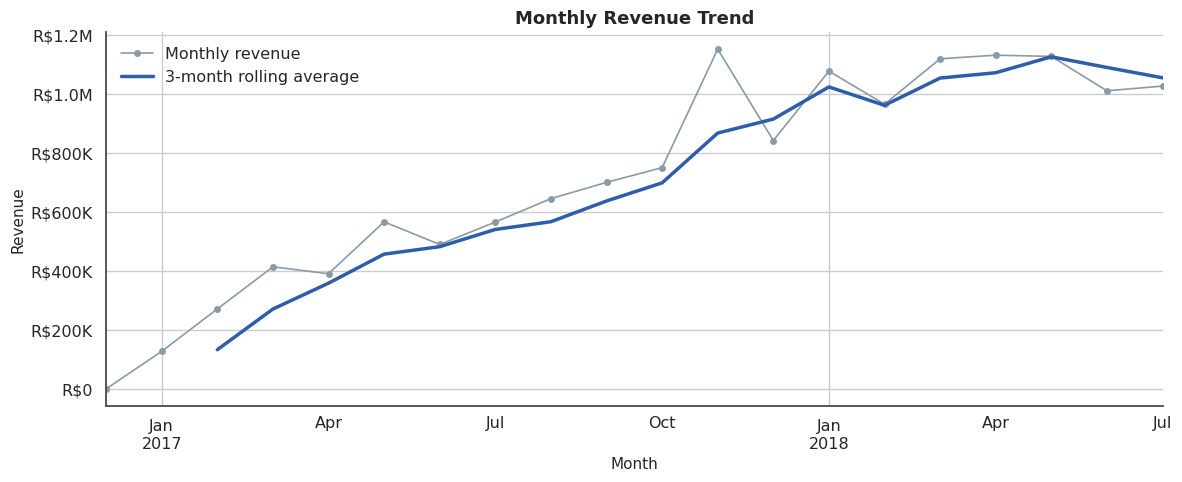

In [26]:
monthly_revenue = A.analyze_monthly_revenue(order_df)
fig = V.plot_monthly_sales(monthly_revenue)
plt.show()


**Business Insight:** Revenue grew from near-zero in late 2016 to a sustained run-rate of roughly R\$1M/month from late 2017 onward, with a pronounced spike around November 2017 consistent with Black Friday seasonality. Since mid-2018 the trend has plateaued rather than continuing to grow.

**Business Impact:** A plateau after rapid early growth is a normal maturity signal for a marketplace, but it also means Olist can no longer rely on organic month-over-month growth to hit revenue targets.

**Recommendation:** Set a specific target for revenue-per-existing-customer (not just topline revenue) in monthly business reviews, and treat the plateau as the trigger for the retention investment discussed in Sections 10 and 18, rather than as a temporary dip to wait out.


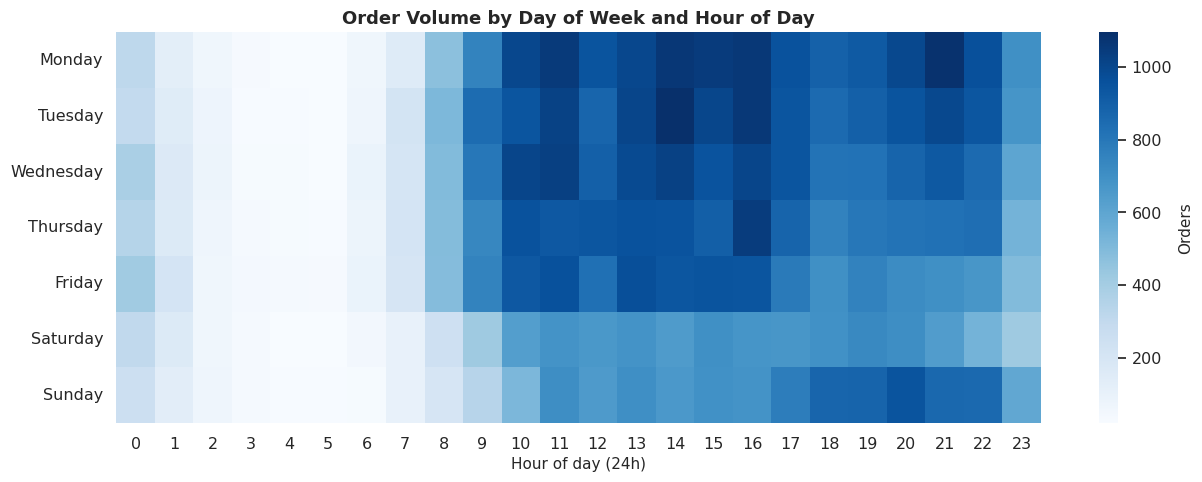

In [27]:
fig = V.plot_seasonality_heatmap(order_df)
plt.show()


**Business Insight:** Ordering activity is concentrated on weekdays during business/evening hours (roughly 10:00–22:00), with a clear drop-off on weekends and overnight.

**Business Impact:** Customer service staffing, flash-sale timing, and paid marketing scheduling are all currently more valuable on weekday afternoons/evenings than weekends.

**Recommendation:** Shift promotional pushes and customer-support staffing to weekday afternoon/evening peaks, and treat weekend campaign spend as lower-priority unless a specific weekend-shopping test shows otherwise.


## 18. RFM Customer Segmentation

**Business question:** Can customers be segmented by value in a way that supports a concrete retention strategy, and which customers are likely to become repeat buyers?


In [28]:
rfm = A.calculate_rfm(order_df)
print(f"Customers with frequency == 1 : {(rfm['frequency'] == 1).mean()*100:.1f}%")
rfm[['recency', 'frequency', 'monetary']].describe()


Customers with frequency == 1 : 97.0%


,recency,frequency,monetary
count,93357.000000,93357.000000,93357.000000
mean,237.936673,1.033420,165.198772
std,152.584315,0.209099,226.314579
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.060000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.560000
max,695.000000,15.000000,13664.080000


**Honest caveat:** Because 97% of customers have `frequency == 1`, a frequency score built on quintiles is not very discriminating here — most customers tie on that dimension. Rather than force a textbook 5x5x5 RFM score that implies more differentiation on frequency than the data actually supports, `analysis.calculate_rfm()` leans primarily on **Recency and Monetary value**, with frequency used only to flag genuine repeat buyers as their own top tier — a more defensible read of this specific dataset.


In [29]:
segment_summary = A.summarize_rfm_segments(rfm)
segment_summary


,customers,avg_monetary,total_monetary,revenue_share_pct
segment,,,,
Standard,68987,88.842807,6128998.76,39.740729
Recent High-Value (one-time),10907,389.406779,4247259.74,27.539441
At-Risk High-Value (one-time),10662,392.219664,4181846.06,27.115295
Repeat Buyer,2801,308.588793,864357.21,5.604535


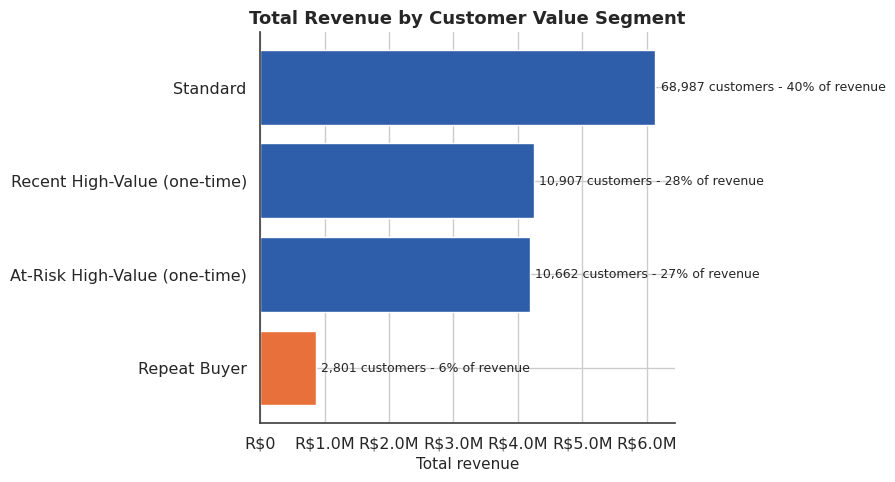

In [30]:
fig = V.plot_rfm_segments(segment_summary)
plt.show()


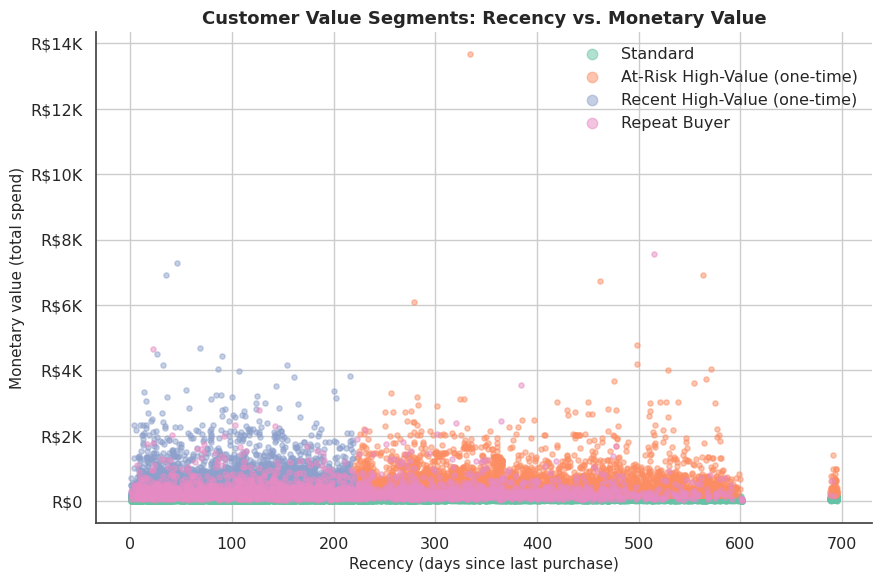

In [31]:
fig = V.plot_rfm_scatter(rfm)
plt.show()


**Business Insight:** Repeat Buyers are a small group (~3% of customers) but generate a disproportionate revenue share relative to their population. Separately, a large pool of one-time **high-value** customers exists — people who spent well above the median in a single order but never returned. The "At-Risk High-Value" slice (high spend, purchased long ago, never repeated) is the clearest untapped opportunity: they've already demonstrated willingness to spend, unlike low-value single-purchase customers who may just be low-intent browsers.

**Business Impact:** Treating all ~90K single-purchase customers as one undifferentiated win-back audience wastes budget on low-value, low-propensity customers. The high-value one-time segment is a much smaller, higher-ROI target than the full retention problem might suggest.

**Recommendation:** Launch the win-back / lifecycle test proposed in Section 10 specifically on the "At-Risk High-Value (one-time)" segment first — the smallest, most targeted, and most defensible group to prove out a retention motion before scaling spend to the full base.


In [32]:
# Which customers are likely to become repeat buyers? A transparent,
# descriptive comparison (not a predictive model -- see Conclusion).
repeat_factors = A.predict_repeat_likelihood_factors(customer_df)
repeat_factors


,avg_first_order_value,avg_review_score,n_customers
is_repeat_customer,,,
False,160.763556,4.139421,90556
True,145.868157,4.194161,2801


**Business Insight:** Customers who went on to repeat do **not** differ much from one-time buyers on their first-order value or review score — repeat buyers' average first order (R\$145.87) is actually slightly *lower* than one-time buyers' (R\$160.76), and review scores are nearly identical (4.19 vs. 4.14). Repeat behavior in this dataset does not appear to be simply "people who had a bigger or better first order."

**Business Impact:** This rules out the simplest hypothesis (spend more to get more loyalty) as a way to predict who will return, and suggests repeat purchasing here is driven by factors this dataset doesn't directly capture (e.g., product category fit, need-based repurchase cycles) rather than transaction size or satisfaction alone.

**Recommendation:** Treat "who will repeat" as an open question requiring a proper predictive model with a wider feature set (category, timing, geography) rather than assuming first-order value or review score alone will identify them — flagged explicitly here rather than overclaiming a simple rule.


## 19. Key Business Insights

1. **Revenue** reached a ~R\$1M/month run-rate by late 2017 and has since plateaued — growth can no longer be assumed to be organic.
2. **Retention is the single biggest structural gap**: only 3.0% of customers ever place a second order, and this cannot be predicted from first-order value or review score alone.
3. **Delivery reliability is a measurable satisfaction driver**: late orders score 2.26/5 on average vs. 4.28/5 for on-time orders — a two-point swing on a five-point scale.
4. **Revenue is concentrated** in the Southeast (SP/RJ/MG = 62.5%) and in a healthy long tail of sellers (top 10 = 13% of revenue — no single-seller risk).
5. **137 sellers are identifiable, consistent underperformers** on delivery and review score, out of sellers with sufficient order volume to judge fairly.
6. **Credit card and installment financing dominate** (75.5% of orders, 3.5+ average installments), and payment method is structurally tied to order size.
7. A **small, identifiable high-value one-time-buyer segment** exists and is the highest-leverage target for a retention pilot.


## 20. Executive Recommendations

| Priority | Action | Rationale |
|---|---|---|
| 1 | Pilot a win-back offer targeted at "At-Risk High-Value (one-time)" customers | Smallest, most defensible test of the retention opportunity |
| 2 | Make on-time delivery rate a headline KPI; add service recovery for late orders | Largest single measurable driver of review score |
| 3 | Review the 137 flagged underperforming sellers through seller operations | Specific, actionable list rather than a diffuse quality problem |
| 4 | Move to state-tiered estimated delivery dates | Directly reduces the *late rate* metric and closes the geography/satisfaction gap |
| 5 | Track average installments as a leading AOV indicator | Financing availability appears structurally tied to order size |
| 6 | Invest in seller quality/logistics support in the long tail, especially outside the Southeast | Addresses delivery variance at its likely source |


## 21. Conclusion

This analysis unified nine relational Olist tables into a single order-level analytical base, then used it to answer eight specific business questions spanning customer value, product/seller performance, delivery reliability, payment behavior, satisfaction, and geography.

The project intentionally stops short of building a predictive churn or CLV model — Section 18 shows that the simplest hypothesis (repeat buyers had bigger or better first orders) doesn't hold, and a proper model would need a wider feature set and a real train/holdout design rather than being bolted onto this descriptive pass. That is flagged here as a deliberate scope boundary, not an oversight, and is the natural next phase of work.

**Project structure note:** All cleaning, feature engineering, KPI/analysis, and charting logic used in this notebook lives in the `src/` package, with an equivalent SQL implementation of the core analyses in `sql/` — see the project `README.md` for the full repository layout and methodology.
